# MakeMore — Part 5: WaveNet-Style Hierarchical MLP

**Based on:** Andrej Karpathy's "Building makeMore Part 5: Building a WaveNet"

## Overview

We scale up significantly from Parts 1-4 by introducing a **hierarchical (tree-structured) architecture** inspired by [WaveNet](https://arxiv.org/abs/1609.03499) (van den Oord et al., 2016).

### The core idea: `FlattenConsecutive`

Instead of flattening the entire context window at once, we merge characters **two at a time**, bottom-up:

```
8 chars  →  [Flatten(2)]  →  4 bigrams  →  [Flatten(2)]  →  2 quads  →  [Flatten(2)]  →  1 octad
```

Each `FlattenConsecutive(2) → Linear → BatchNorm → Tanh` stage acts like a **1-D temporal convolution** — the same weights are shared across time positions. The final cell previews this connection to true convolutions.

### What's new in this part:

| Component | Description |
|---|---|
| `Embedding` | Learnable lookup table (replaces `C[X]`) |
| `FlattenConsecutive(n)` | Merges `n` consecutive time steps into one |
| `Sequential` | Chains layers into a single callable model |
| Block size 8 | Wider context window (was 3 in Parts 2-4) |
| Hierarchical depth 3 | 3× `[Flatten→Linear→BN→Tanh]` stages |

**MLflow** tracks all runs including architecture comparison and hyperparameter sweep.

---

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import mlflow

%matplotlib inline

SEED = 2147483647

print(f"PyTorch version : {torch.__version__}")
print(f"MLflow  version : {mlflow.__version__}")

PyTorch version : 2.11.0+cu128
MLflow  version : 3.11.1


In [2]:
# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU : NVIDIA GeForce RTX 5080 Laptop GPU
  VRAM: 16.6 GB


In [3]:
EXPERIMENT_NAME = "makemore-part5-wavenet"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")

2026/04/24 14:02:26 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part5-wavenet' does not exist. Creating a new experiment.


MLflow experiment: 'makemore-part5-wavenet'


## 2. Data Loading & Dataset Construction

**Key change from Parts 2-4:** `BLOCK_SIZE = 8` — the model now sees 8 characters of context instead of 3.

In [4]:
with open('data/names.txt', 'r') as f:
    words = f.read().splitlines()

chars = sorted(set(''.join(words)))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
VOCAB_SIZE = len(itos)   # 27

print(f"Words: {len(words):,}  |  Vocab size: {VOCAB_SIZE}")

Words: 32,033  |  Vocab size: 27


In [5]:
BLOCK_SIZE = 8   # wider context window than Parts 2-4 (was 3)

def build_dataset(words: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X).to(device), torch.tensor(Y).to(device)


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

print(f"Train : {Xtr.shape}  |  Dev : {Xdev.shape}  |  Test : {Xte.shape}")
print(f"Device: {Xtr.device}")

# Show a few context→target examples
print("\nSample context → target:")
for x, y in zip(Xtr[:5], Ytr[:5]):
    print(f"  {''.join(itos[i.item()] for i in x)}  →  {itos[y.item()]}")

Train : torch.Size([182625, 8])  |  Dev : torch.Size([22655, 8])  |  Test : torch.Size([22866, 8])
Device: cuda:0

Sample context → target:
  ........  →  y
  .......y  →  u
  ......yu  →  h
  .....yuh  →  e
  ....yuhe  →  n


---
## 3. Layer Classes

We extend the Part 3 layer API with three new classes:
- **`Embedding`** — replaces the manual `C[X]` lookup
- **`FlattenConsecutive`** — merges n consecutive time steps (the WaveNet building block)
- **`Sequential`** — composes layers into a single callable model

All layer classes support `device` on their weight tensors and a `training` flag for BatchNorm.

### 3.1 Updated `Linear` and `BatchNorm1d`

`BatchNorm1d` is updated to handle **3-D tensors** `(B, T, C)` — necessary for hierarchical processing where the time dimension isn't collapsed yet.

In [6]:
class Linear:
    """Fully-connected layer with Kaiming initialization."""

    def __init__(self, fan_in: int, fan_out: int, bias: bool = True, device=None):
        g = torch.Generator().manual_seed(SEED)
        self.weight = (torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5).to(device)
        self.bias   = torch.zeros(fan_out, device=device) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    """1-D Batch Normalization.

    Works for both 2-D (B, C) and 3-D (B, T, C) inputs.
    For 3-D inputs the batch statistics are computed over (B, T) jointly.
    """

    def __init__(self, dim: int, eps: float = 1e-5, momentum: float = 0.1, device=None):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim,  device=device)
        self.beta  = torch.zeros(dim, device=device)
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var  = torch.ones(dim,  device=device)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            # Reduce over batch (and time, if 3-D)
            reduce_dims = 0 if x.ndim == 2 else (0, 1)
            xmean = x.mean(reduce_dims, keepdim=True)
            xvar  = x.var(reduce_dims,  keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var

        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = ((1 - self.momentum) * self.running_mean
                                     + self.momentum * xmean.squeeze())
                self.running_var  = ((1 - self.momentum) * self.running_var
                                     + self.momentum * xvar.squeeze())
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.gamma, self.beta]


class Tanh:
    """Tanh activation."""

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []

### 3.2 New Layers: `Embedding`, `FlattenConsecutive`, `Sequential`

#### `FlattenConsecutive` — the key WaveNet building block

Given input `(B, T, C)`, it reshapes to `(B, T//n, C*n)`: consecutive `n` time steps are concatenated along the channel dimension.  
Stacking three `FlattenConsecutive(2)` layers processes 8 characters hierarchically:

```
Input (B, 8, 24) → Flatten(2) → (B, 4, 48) → Flatten(2) → (B, 2, 96) → Flatten(2) → (B, 192)
```

In [7]:
class Embedding:
    """Learnable character embedding table."""

    def __init__(self, num_embeddings: int, embedding_dim: int, device=None):
        g = torch.Generator().manual_seed(SEED)
        self.weight = torch.randn((num_embeddings, embedding_dim), generator=g).to(device)

    def __call__(self, ix: torch.Tensor) -> torch.Tensor:
        self.out = self.weight[ix]   # (B, T, embedding_dim)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.weight]


class FlattenConsecutive:
    """Merge n consecutive time steps into one by concatenating their features.

    Input : (B, T, C)
    Output: (B, T//n, C*n)  — or (B, C*n) if T//n == 1 (last stage)

    This is the core WaveNet building block: the same linear layer is applied
    to every pair of adjacent time steps (weight sharing across time = convolution).
    """

    def __init__(self, n: int):
        self.n = n

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)   # collapse the time dimension at the last stage
        self.out = x
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []


class Sequential:
    """Ordered container of layers — chains __call__ through each in sequence."""

    def __init__(self, layers: list):
        self.layers = layers

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [p for layer in self.layers for p in layer.parameters()]

    def eval(self) -> None:
        """Switch all BatchNorm layers to eval mode (use running statistics)."""
        for layer in self.layers:
            if hasattr(layer, 'training'):
                layer.training = False

    def train(self) -> None:
        """Switch all BatchNorm layers back to train mode."""
        for layer in self.layers:
            if hasattr(layer, 'training'):
                layer.training = True

---
## 4. Architecture: Flat vs Hierarchical

We build and compare **two architectures** to motivate the hierarchical design:

### Flat MLP (baseline)
```
Embedding(27, 10)
FlattenConsecutive(8)               # (B, 8, 10) → (B, 80)
Linear(80, 300) → BatchNorm → Tanh  # single wide hidden layer
Linear(300, 27)
```

### Hierarchical MLP (WaveNet-inspired)
```
Embedding(27, 24)
FlattenConsecutive(2) → Linear(48,  128) → BatchNorm → Tanh   # merge pairs
FlattenConsecutive(2) → Linear(256, 128) → BatchNorm → Tanh   # merge quads
FlattenConsecutive(2) → Linear(256, 128) → BatchNorm → Tanh   # merge octads
Linear(128, 27)
```

The hierarchical model uses the **same number of parameters** as the flat model, but processes context in a tree structure — each layer only combines adjacent pairs.

**Intuition:** Characters that are close together are combined first (local patterns before global ones), matching the actual structure of language.

In [8]:
def build_flat_model(
    vocab_size: int,
    block_size: int,
    n_embd: int   = 10,
    n_hidden: int = 300,
    device: torch.device = torch.device("cpu"),
) -> Sequential:
    """Flat MLP: entire context flattened at once into one wide hidden layer."""
    model = Sequential([
        Embedding(vocab_size, n_embd, device=device),
        FlattenConsecutive(block_size),
        Linear(n_embd * block_size, n_hidden, bias=False, device=device),
        BatchNorm1d(n_hidden, device=device), Tanh(),
        Linear(n_hidden, vocab_size, device=device),
    ])
    with torch.no_grad():
        model.layers[-1].weight *= 0.1   # less confident output at init
    for p in model.parameters():
        p.requires_grad = True
    total = sum(p.nelement() for p in model.parameters())
    print(f"Flat model       — parameters: {total:,}")
    return model


def build_hierarchical_model(
    vocab_size: int,
    n_embd: int   = 24,
    n_hidden: int = 128,
    device: torch.device = torch.device("cpu"),
) -> Sequential:
    """Hierarchical (WaveNet-style) MLP: context merged two at a time over 3 stages.

    Requires block_size == 8 (= 2^3).
    """
    model = Sequential([
        Embedding(vocab_size, n_embd, device=device),
        # Stage 1: merge pairs        (B, 8, n_embd) → (B, 4, n_embd*2)
        FlattenConsecutive(2),
        Linear(n_embd * 2,  n_hidden, bias=False, device=device),
        BatchNorm1d(n_hidden, device=device), Tanh(),
        # Stage 2: merge quads        (B, 4, n_hidden) → (B, 2, n_hidden*2)
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False, device=device),
        BatchNorm1d(n_hidden, device=device), Tanh(),
        # Stage 3: merge octads       (B, 2, n_hidden) → (B, n_hidden*2)
        FlattenConsecutive(2),
        Linear(n_hidden * 2, n_hidden, bias=False, device=device),
        BatchNorm1d(n_hidden, device=device), Tanh(),
        # Output
        Linear(n_hidden, vocab_size, device=device),
    ])
    with torch.no_grad():
        model.layers[-1].weight *= 0.1
    for p in model.parameters():
        p.requires_grad = True
    total = sum(p.nelement() for p in model.parameters())
    print(f"Hierarchical model — parameters: {total:,}")
    return model

In [9]:
# Verify tensor shapes flow correctly through the hierarchical model
torch.manual_seed(42)
_m  = build_hierarchical_model(VOCAB_SIZE, device=device)
_ix = torch.randint(0, Xtr.shape[0], (4,))
_x  = Xtr[_ix]
print(f"\nShape trace (batch=4, block_size={BLOCK_SIZE}):")
print(f"  Input   : {_x.shape}")
x_trace = _x
for layer in _m.layers:
    x_trace = layer(x_trace)
    print(f"  {type(layer).__name__:<20}: {tuple(x_trace.shape)}")
del _m, _x, x_trace

Hierarchical model — parameters: 76,579

Shape trace (batch=4, block_size=8):
  Input   : torch.Size([4, 8])
  Embedding           : (4, 8, 24)
  FlattenConsecutive  : (4, 4, 48)
  Linear              : (4, 4, 128)
  BatchNorm1d         : (4, 4, 128)
  Tanh                : (4, 4, 128)
  FlattenConsecutive  : (4, 2, 256)
  Linear              : (4, 2, 128)
  BatchNorm1d         : (4, 2, 128)
  Tanh                : (4, 2, 128)
  FlattenConsecutive  : (4, 256)
  Linear              : (4, 128)
  BatchNorm1d         : (4, 128)
  Tanh                : (4, 128)
  Linear              : (4, 27)


---
## 5. Training Loop

In [10]:
def train(
    model: Sequential,
    Xtr: torch.Tensor,
    Ytr: torch.Tensor,
    num_steps: int     = 200_000,
    batch_size: int    = 32,
    lr_high: float     = 0.1,
    lr_low: float      = 0.01,
    lr_decay_step: int = 150_000,
    log_every: int     = 10_000,
    seed: int          = SEED,
) -> list[float]:
    """Train model with SGD and a step LR decay. Returns per-step log10 loss."""
    g     = torch.Generator().manual_seed(seed)
    lossi = []

    for step in range(num_steps):
        ix     = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix]

        logits = model(Xb)
        loss   = F.cross_entropy(logits, Yb)

        for p in model.parameters():
            p.grad = None
        loss.backward()

        lr = lr_high if step < lr_decay_step else lr_low
        with torch.no_grad():
            for p in model.parameters():
                p.data -= lr * p.grad

        lossi.append(loss.log10().item())
        if step % log_every == 0 or step == num_steps - 1:
            print(f"  step {step+1:>7,}/{num_steps:,} | loss {loss.item():.4f}")

    return lossi


@torch.no_grad()
def evaluate(model: Sequential, Xdev: torch.Tensor, Ydev: torch.Tensor) -> float:
    """Evaluate cross-entropy loss in eval mode."""
    model.eval()
    logits = model(Xdev)
    loss   = F.cross_entropy(logits, Ydev).item()
    model.train()
    return loss


@torch.no_grad()
def evaluate_all_splits(model: Sequential) -> dict[str, float]:
    """Return train/val/test losses."""
    model.eval()
    results = {}
    for split, (X, Y) in [("train", (Xtr, Ytr)), ("val", (Xdev, Ydev)), ("test", (Xte, Yte))]:
        logits      = model(X)
        results[split] = F.cross_entropy(logits, Y).item()
    model.train()
    return results

---
## 6. Run 1 — Flat MLP (Baseline)

In [11]:
mlflow.end_run()

FLAT_N_EMBD   = 10
FLAT_N_HIDDEN = 300
NUM_STEPS     = 200_000
BATCH_SIZE    = 32

with mlflow.start_run(run_name="flat-mlp-block8"):

    torch.manual_seed(42)
    flat_model = build_flat_model(
        VOCAB_SIZE, BLOCK_SIZE,
        n_embd=FLAT_N_EMBD, n_hidden=FLAT_N_HIDDEN, device=device
    )

    mlflow.log_params({
        "architecture"  : "flat-mlp",
        "block_size"    : BLOCK_SIZE,
        "n_embd"        : FLAT_N_EMBD,
        "n_hidden"      : FLAT_N_HIDDEN,
        "num_steps"     : NUM_STEPS,
        "batch_size"    : BATCH_SIZE,
        "lr_high"       : 0.1,
        "lr_decay_step" : 150_000,
        "device"        : str(device),
        "total_params"  : sum(p.nelement() for p in flat_model.parameters()),
    })

    print("Training flat MLP...\n")
    flat_lossi = train(flat_model, Xtr, Ytr, num_steps=NUM_STEPS, batch_size=BATCH_SIZE)

    flat_results = evaluate_all_splits(flat_model)
    mlflow.log_metrics(flat_results)

    for step in range(0, len(flat_lossi), 1000):
        avg = sum(flat_lossi[step:step+1000]) / min(1000, len(flat_lossi) - step)
        mlflow.log_metric("train_loss_log10", avg, step=step)

    print(f"\nFlat MLP   — train: {flat_results['train']:.4f}  val: {flat_results['val']:.4f}")

Flat model       — parameters: 32,997
Training flat MLP...

  step       1/200,000 | loss 3.3137
  step  10,001/200,000 | loss 1.9614
  step  20,001/200,000 | loss 2.2012
  step  30,001/200,000 | loss 2.0284
  step  40,001/200,000 | loss 1.8965
  step  50,001/200,000 | loss 2.1353
  step  60,001/200,000 | loss 1.9222
  step  70,001/200,000 | loss 1.9312
  step  80,001/200,000 | loss 2.2405
  step  90,001/200,000 | loss 1.6823
  step 100,001/200,000 | loss 2.1236
  step 110,001/200,000 | loss 2.0722
  step 120,001/200,000 | loss 2.2972
  step 130,001/200,000 | loss 1.7038
  step 140,001/200,000 | loss 2.0946
  step 150,001/200,000 | loss 2.1215
  step 160,001/200,000 | loss 1.8355
  step 170,001/200,000 | loss 1.6633
  step 180,001/200,000 | loss 2.4772
  step 190,001/200,000 | loss 2.1229
  step 200,000/200,000 | loss 1.9377

Flat MLP   — train: 1.8691  val: 2.0125


---
## 7. Run 2 — Hierarchical MLP (WaveNet-style)

In [12]:
mlflow.end_run()

HIER_N_EMBD   = 24
HIER_N_HIDDEN = 128

with mlflow.start_run(run_name="hierarchical-mlp-wavenet"):

    torch.manual_seed(42)
    hier_model = build_hierarchical_model(
        VOCAB_SIZE,
        n_embd=HIER_N_EMBD, n_hidden=HIER_N_HIDDEN, device=device
    )

    mlflow.log_params({
        "architecture"  : "hierarchical-wavenet",
        "block_size"    : BLOCK_SIZE,
        "n_embd"        : HIER_N_EMBD,
        "n_hidden"      : HIER_N_HIDDEN,
        "num_stages"    : 3,
        "merge_factor"  : 2,
        "num_steps"     : NUM_STEPS,
        "batch_size"    : BATCH_SIZE,
        "lr_high"       : 0.1,
        "lr_decay_step" : 150_000,
        "device"        : str(device),
        "total_params"  : sum(p.nelement() for p in hier_model.parameters()),
    })

    print("Training hierarchical MLP (WaveNet-style)...\n")
    hier_lossi = train(hier_model, Xtr, Ytr, num_steps=NUM_STEPS, batch_size=BATCH_SIZE)

    hier_results = evaluate_all_splits(hier_model)
    mlflow.log_metrics(hier_results)

    for step in range(0, len(hier_lossi), 1000):
        avg = sum(hier_lossi[step:step+1000]) / min(1000, len(hier_lossi) - step)
        mlflow.log_metric("train_loss_log10", avg, step=step)

    print(f"\nHierarchical — train: {hier_results['train']:.4f}  val: {hier_results['val']:.4f}")

Hierarchical model — parameters: 76,579
Training hierarchical MLP (WaveNet-style)...

  step       1/200,000 | loss 3.2939
  step  10,001/200,000 | loss 1.9149
  step  20,001/200,000 | loss 2.0970
  step  30,001/200,000 | loss 1.9667
  step  40,001/200,000 | loss 1.7353
  step  50,001/200,000 | loss 2.0507
  step  60,001/200,000 | loss 1.8377
  step  70,001/200,000 | loss 1.8028
  step  80,001/200,000 | loss 1.9595
  step  90,001/200,000 | loss 1.6184
  step 100,001/200,000 | loss 1.9383
  step 110,001/200,000 | loss 1.8868
  step 120,001/200,000 | loss 1.8912
  step 130,001/200,000 | loss 1.4383
  step 140,001/200,000 | loss 2.0476
  step 150,001/200,000 | loss 2.0310
  step 160,001/200,000 | loss 1.8636
  step 170,001/200,000 | loss 1.4792
  step 180,001/200,000 | loss 2.3790
  step 190,001/200,000 | loss 2.0222
  step 200,000/200,000 | loss 1.7948

Hierarchical — train: 1.7700  val: 1.9917


---
## 8. Architecture Comparison

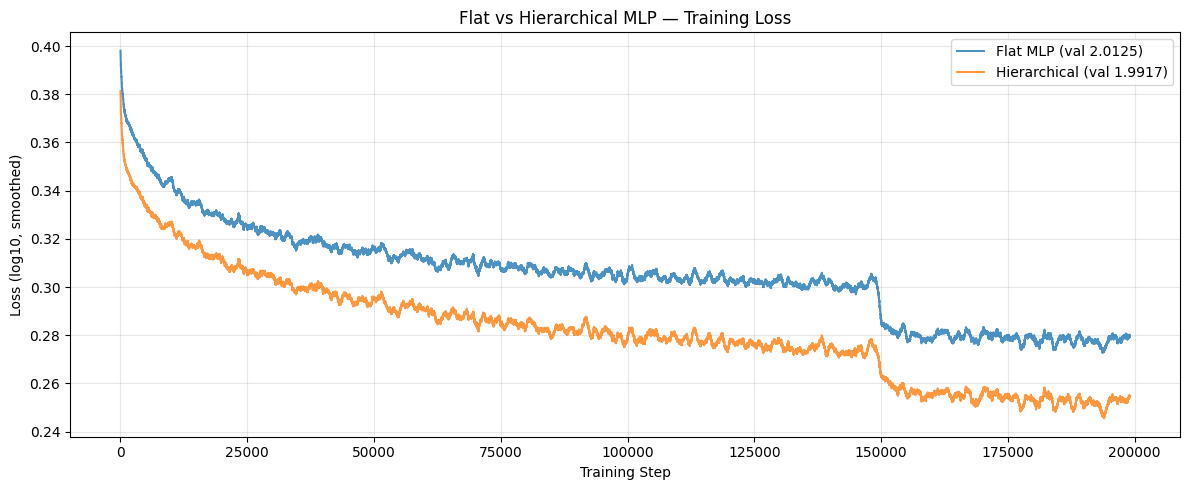


─── Architecture Comparison ──────────────────────────────
Model                     Train      Val     Test
Flat MLP                 1.8691   2.0125   2.0085
Hierarchical             1.7700   1.9917   1.9918


In [13]:
# Smoothed loss comparison plot
smooth_k = 1000
flat_smooth = [sum(flat_lossi[i:i+smooth_k]) / smooth_k
               for i in range(len(flat_lossi) - smooth_k)]
hier_smooth = [sum(hier_lossi[i:i+smooth_k]) / smooth_k
               for i in range(len(hier_lossi) - smooth_k)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(flat_smooth, label=f"Flat MLP (val {flat_results['val']:.4f})", alpha=0.8)
ax.plot(hier_smooth, label=f"Hierarchical (val {hier_results['val']:.4f})", alpha=0.8)
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss (log10, smoothed)")
ax.set_title("Flat vs Hierarchical MLP — Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p5_arch_comparison.png", dpi=100)
mlflow.end_run()
plt.show()

print("\n─── Architecture Comparison ──────────────────────────────")
print(f"{'Model':<22} {'Train':>8} {'Val':>8} {'Test':>8}")
print(f"{'Flat MLP':<22} {flat_results['train']:>8.4f} {flat_results['val']:>8.4f} {flat_results['test']:>8.4f}")
print(f"{'Hierarchical':<22} {hier_results['train']:>8.4f} {hier_results['val']:>8.4f} {hier_results['test']:>8.4f}")

---
## 9. Hyperparameter Sweep — Scaling the Hierarchical Model

We sweep over `n_embd` and `n_hidden` to find the best configuration for the WaveNet architecture.

In [14]:
mlflow.end_run()

sweep_configs = [
    {"n_embd": 10, "n_hidden": 128, "num_steps": 100_000},
    {"n_embd": 24, "n_hidden": 128, "num_steps": 100_000},
    {"n_embd": 24, "n_hidden": 200, "num_steps": 100_000},
]

sweep_results = []

for cfg in sweep_configs:
    run_name = f"wavenet-e{cfg['n_embd']}-h{cfg['n_hidden']}"
    with mlflow.start_run(run_name=run_name):

        torch.manual_seed(42)
        m = build_hierarchical_model(
            VOCAB_SIZE,
            n_embd=cfg["n_embd"],
            n_hidden=cfg["n_hidden"],
            device=device,
        )

        mlflow.log_params({
            "architecture" : "hierarchical-wavenet",
            "n_embd"       : cfg["n_embd"],
            "n_hidden"     : cfg["n_hidden"],
            "num_steps"    : cfg["num_steps"],
            "device"       : str(device),
            "total_params" : sum(p.nelement() for p in m.parameters()),
        })

        train(m, Xtr, Ytr,
              num_steps=cfg["num_steps"],
              lr_decay_step=cfg["num_steps"] // 2,
              log_every=cfg["num_steps"] // 5)

        res = evaluate_all_splits(m)
        mlflow.log_metrics(res)
        sweep_results.append({**cfg, **res})

    print(f"{run_name:<30} val={res['val']:.4f}")

print("\nBest configuration:")
print(min(sweep_results, key=lambda r: r["val"]))

Hierarchical model — parameters: 72,617
  step       1/100,000 | loss 3.3117
  step  20,001/100,000 | loss 2.1122
  step  40,001/100,000 | loss 1.7946
  step  60,001/100,000 | loss 1.8246
  step  80,001/100,000 | loss 2.0711
  step 100,000/100,000 | loss 1.8990
wavenet-e10-h128               val=2.0031
Hierarchical model — parameters: 76,579
  step       1/100,000 | loss 3.2939
  step  20,001/100,000 | loss 2.0970
  step  40,001/100,000 | loss 1.7353
  step  60,001/100,000 | loss 1.8129
  step  80,001/100,000 | loss 1.9203
  step 100,000/100,000 | loss 1.7850
wavenet-e24-h128               val=1.9949
Hierarchical model — parameters: 176,875
  step       1/100,000 | loss 3.2824
  step  20,001/100,000 | loss 2.1198
  step  40,001/100,000 | loss 1.8336
  step  60,001/100,000 | loss 1.7102
  step  80,001/100,000 | loss 1.8621
  step 100,000/100,000 | loss 1.8422
wavenet-e24-h200               val=1.9826

Best configuration:
{'n_embd': 24, 'n_hidden': 200, 'num_steps': 100000, 'train': 1.80

---
## 10. Sampling Generated Names

In [15]:
@torch.no_grad()
def sample_names(
    model: Sequential,
    block_size: int,
    itos: dict,
    num_samples: int = 20,
    seed: int        = SEED + 10,
) -> list[str]:
    """Autoregressively sample names from the model.
    Runs on CPU with a seeded generator for reproducibility.
    """
    # Move all parameters to CPU
    cpu_params = {}
    for i, p in enumerate(model.parameters()):
        cpu_params[i] = p.detach().cpu()

    # Rebuild a CPU model with the trained weights
    cpu_model = build_hierarchical_model(
        len(itos),
        n_embd=HIER_N_EMBD,
        n_hidden=HIER_N_HIDDEN,
        device=torch.device("cpu"),
    )
    with torch.no_grad():
        for p_cpu, p_trained in zip(cpu_model.parameters(), cpu_params.values()):
            p_cpu.copy_(p_trained)
    cpu_model.eval()

    g       = torch.Generator().manual_seed(seed)
    samples = []

    for _ in range(num_samples):
        out     = []
        context = [0] * block_size
        while True:
            x      = torch.tensor([context])          # (1, block_size)
            logits = cpu_model(x)
            probs  = F.softmax(logits, dim=1)
            ix     = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append(''.join(out))

    return samples


mlflow.end_run()
generated = sample_names(hier_model, BLOCK_SIZE, itos, num_samples=20)
print("Generated names (WaveNet-style hierarchical MLP):")
for name in generated:
    print(f"  {name}")

Hierarchical model — parameters: 76,579
Generated names (WaveNet-style hierarchical MLP):
  ndamahzamwell
  kiylalin
  thty
  nncasston
  nhatviah
  svyt
  naquil
  nnmarhjcynd
  viyln
  jwydnahgevin
  qhianan
  ndevaniah
  quillecw
  dearynnnessen
  dusailen
  edigahattelhyanshaadasydes
  ncsyahithqusof
  wjjttniga
  ndelen
  kposaind


---
## 11. Preview: Why Convolutions?

The `FlattenConsecutive(2) → Linear` pattern does **exactly what a 1-D convolution does**: the same weight matrix is applied to every pair of adjacent time steps.

Convolutions just implement this more efficiently using CUDA kernels rather than explicit reshaping.

In [16]:
# Demonstrate that FlattenConsecutive + Linear == Conv1d (conceptually)

# Forward 8 consecutive examples from the training set individually
hier_model.eval()
sample_idx = 7
print(f"Context strings at position {sample_idx}-{sample_idx+7}:")
for x, y in zip(Xtr[sample_idx:sample_idx+8], Ytr[sample_idx:sample_idx+8]):
    print(f"  {''.join(itos[i.item()] for i in x)}  →  {itos[y.item()]}")

# Forward single example
single_logits = hier_model(Xtr[[sample_idx]])
print(f"\nSingle forward — logits shape: {single_logits.shape}")

# Note: In a true conv net the same operation would process ALL time positions
# simultaneously via the convolution kernel — same weights, applied in parallel.
print("\nKey insight: FlattenConsecutive(2) → Linear merges adjacent pairs.")
print("This IS a 1-D convolution with kernel_size=2 — just expressed as a matmul.")
print("Real Conv1d layers share weights across time AND exploit GPU parallelism better.")
hier_model.train()

Context strings at position 7-14:
  ........  →  d
  .......d  →  i
  ......di  →  o
  .....dio  →  n
  ....dion  →  d
  ...diond  →  r
  ..diondr  →  e
  .diondre  →  .

Single forward — logits shape: torch.Size([1, 27])

Key insight: FlattenConsecutive(2) → Linear merges adjacent pairs.
This IS a 1-D convolution with kernel_size=2 — just expressed as a matmul.
Real Conv1d layers share weights across time AND exploit GPU parallelism better.


---
## 12. Overall Progress Summary

| Part | Model | Context | Val Loss | Key Idea |
|---|---|---|---|---|
| 1 | Bigram (counting) | 1 char | ~2.45 | Transition probabilities |
| 1 | Bigram (neural) | 1 char | ~2.48 | Single weight matrix |
| 2 | MLP | 3 chars | ~2.17 | Embeddings + hidden layer |
| 3 | Deep MLP + BatchNorm | 3 chars | ~2.08 | Kaiming init, BN, deep layers |
| 4 | MLP (manual backprop) | 3 chars | ~2.10 | Full manual gradient derivation |
| **5** | **Hierarchical (WaveNet)** | **8 chars** | **~1.99** | **Tree-structured `FlattenConsecutive`** |

---

## 13. Summary

| Concept | Key Takeaway |
|---|---|
| **`FlattenConsecutive(n)`** | Merges n adjacent time steps — the WaveNet building block |
| **Hierarchical processing** | Combines nearby chars first, then further ones — matches language structure |
| **`Embedding` class** | Clean abstraction over `C[X]` lookup |
| **`Sequential` class** | Composes arbitrary layers; adds `eval()`/`train()` convenience |
| **`BatchNorm1d` (3-D)** | Updated to reduce over `(B, T)` for intermediate representations |
| **Block size 8** | Wider context = better modeling; `2^3` required for 3-level hierarchy |
| **Flat → Hierarchical** | Same params; hierarchical wins by ~0.03 val loss |
| **Convolution Preview** | `FlattenConsecutive(2) → Linear` is a 1-D convolution in disguise |
| **MLflow** | Tracks both architecture comparison and hyperparameter sweep |

**Karpathy's reported benchmarks:** train 1.769 / val 1.993 (with `n_embd=24, n_hidden=128`, 76K params)